# Room Merge Case Study

**Candidate:** Sagar Kumar

**Objective:** Predict whether two room records from different GDS providers refer to the same underlying hotel room.

### Problem Statement

OTA(Online Travel Agent) receive hotel room information from multiple GDSs. Since each provider may use different naming conventions, descriptions, and attributes for the same room, identical rooms can appear as separate listings.

The objective of this case study is to build a machine learning model that predicts the probability that a room from **GDS A** and a room from **GDS B** refer to the same underlying hotel room.

---

### Approach

1. Exploratory Data Analysis
2. Data Cleaning
3. Missing Value Recovery
4. Splitting & Negative Sampling
5. Feature Engineering
6. Model Training (Training/Retraining/Evaluation)
7. Conclusion

# Libraries

In [ ]:
import re
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    log_loss, confusion_matrix, classification_report)


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords
from rapidfuzz import fuzz 
from num2words import num2words # To convert numbers into number words
# from sentence_transformers import SentenceTransformer
# from sklearn.metrics.pairwise import cosine_similarity

# Exploratory Data Analysis

In [2]:
# Reading data
data = pd.read_csv("room_merge_positive_samples.csv")

In [3]:
print(f"Number of Rows: {data.shape[0]}")
print(f"Number of Columns: {data.shape[1]}")
print(f"Columns: {data.columns.to_list()}")
print(f"No. of unique hotels: {data['hotel_id'].nunique()}")
print(f"No. of unique gds b rooms: {data['gds_b_room_id'].nunique()}")
print(f"No. of unique gds a rooms: {data['gds_a_room_id'].nunique()}")

Number of Rows: 10000
Number of Columns: 21
Columns: ['hotel_id', 'gds_b_room_id', 'gds_b_room_name', 'gds_b_room_description', 'gds_b_room_amenities', 'gds_b_bedding', 'gds_b_room_type', 'gds_b_views', 'gds_b_smoking', 'gds_b_accessibility', 'gds_b_amenities', 'gds_a_room_id', 'gds_a_room_name', 'gds_a_room_description', 'gds_a_room_amenities', 'gds_a_bedding', 'gds_a_room_type', 'gds_a_views', 'gds_a_smoking', 'gds_a_accessibility', 'gds_a_amenities']
No. of unique hotels: 2282
No. of unique gds b rooms: 8480
No. of unique gds a rooms: 9752


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hotel_id                10000 non-null  int64  
 1   gds_b_room_id           10000 non-null  int64  
 2   gds_b_room_name         10000 non-null  object 
 3   gds_b_room_description  9914 non-null   object 
 4   gds_b_room_amenities    0 non-null      float64
 5   gds_b_bedding           9160 non-null   object 
 6   gds_b_room_type         4029 non-null   object 
 7   gds_b_views             703 non-null    object 
 8   gds_b_smoking           1392 non-null   object 
 9   gds_b_accessibility     367 non-null    object 
 10  gds_b_amenities         0 non-null      float64
 11  gds_a_room_id           10000 non-null  int64  
 12  gds_a_room_name         10000 non-null  object 
 13  gds_a_room_description  10000 non-null  object 
 14  gds_a_room_amenities    5165 non-null  

In [5]:
# Summary statistics
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel_id,10000.0,NaN,NaN,NaN,947045866579913856.0,279637334649027072.0,103373112016280.0,1012616453599705984.0,1033423484432817408.0,1055819554662354816.0,1077288062839738880.0
gds_b_room_id,10000.0,NaN,NaN,NaN,327433770.8173,438545966.109612,4257.0,24445718.0,66692118.5,565092352.5,1622022603.0
gds_b_room_name,10000,3271,Standard Double Room,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gds_b_room_description,9914,6932,This room has free WiFi and a flat-screen TV. ...,188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gds_b_room_amenities,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gds_b_bedding,9160,460,1King bed(s),1944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gds_b_room_type,4029,8,STANDARD,1357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gds_b_views,703,7,SEA,241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gds_b_smoking,1392,2,SMOKING,1383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gds_b_accessibility,367,1,ACCESSIBLE,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
rooms_per_hotel = data.groupby("hotel_id").size().describe()
rooms_per_hotel

count    2282.000000
mean        4.382121
std         7.009882
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       188.000000
dtype: float64

In [7]:
#Missing Values and percentage
missing_values = data.isnull().sum().reset_index()
missing_values.columns = ['cols', 'missing_value_cnt']
missing_values['missing_value_percentage'] = (missing_values['missing_value_cnt'] / len(data)) * 100
missing_values.sort_values(by = 'missing_value_percentage', ascending = False, inplace = True)
missing_values

,cols,missing_value_cnt,missing_value_percentage
10,gds_b_amenities,10000,100.00
4,gds_b_room_amenities,10000,100.00
9,gds_b_accessibility,9633,96.33
19,gds_a_accessibility,9311,93.11
7,gds_b_views,9297,92.97
17,gds_a_views,9243,92.43
8,gds_b_smoking,8608,86.08
6,gds_b_room_type,5971,59.71
18,gds_a_smoking,5306,53.06
16,gds_a_room_type,5216,52.16


In [8]:
#Duplicate Values
print(f"Number of duplicate rows: {data.duplicated().sum()}")
print(f"Number of duplicate B<->A pairs: {data[['gds_b_room_id','gds_a_room_id']].duplicated().sum()}")


Number of duplicate rows: 174
Number of duplicate B<->A pairs: 248


In [9]:
# 1-to-1 Mapping of gds B/gds A rooms
mapping_b = data.groupby('gds_b_room_id').agg(
    map_b = ('gds_a_room_id', 'nunique')
    ).sort_values(by = 'map_b', ascending=False)

mapping_a = data.groupby('gds_a_room_id').agg(
    map_a = ('gds_b_room_id', 'nunique')
    ).sort_values(by = 'map_a', ascending=False)

print(mapping_b.describe())
print()
print(mapping_a.describe())

             map_b
count  8480.000000
mean      1.150000
std       1.864093
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max      87.000000

        map_a
count  9752.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0


In [10]:
# Checking room_id if room_id have more than 1 name associated with it
room_pair_with_names = data.groupby(['gds_b_room_id','gds_a_room_id']).agg(
        b_names=('gds_b_room_name','nunique'),
        a_names=('gds_a_room_name','nunique')
    )
room_pair_with_names[(room_pair_with_names['b_names'] > 1) | (room_pair_with_names['a_names'] > 1)]

,,b_names,a_names
gds_b_room_id,gds_a_room_id,,
714311904,340567685,1,2
714311905,340567686,1,2


In [117]:
# Checking the casing for text in room name and description to understand if the casing is consistent/inconsistent
text_cols = ["gds_b_room_name", "gds_a_room_name", "gds_b_room_description", "gds_a_room_description"]

for col in text_cols:
    upper = data[col].fillna("").str.isupper().sum()
    lower = data[col].fillna("").str.islower().sum()
    title = data[col].fillna("").str.istitle().sum()

    print(f"\n{col}")
    print(f"Upper : {upper}")
    print(f"Lower : {lower}")
    print(f"Title : {title}")


gds_b_room_name
Upper : 10
Lower : 1
Title : 5197

gds_a_room_name
Upper : 202
Lower : 75
Title : 6286

gds_b_room_description
Upper : 0
Lower : 0
Title : 0

gds_a_room_description
Upper : 202
Lower : 75
Title : 6286


In [12]:
# To check the delimitors or special symbols
delimiters = ['/', '-', '|', ',', ';', '&', '+', '(', ')', '[', ']']
# text_cols = data.select_dtypes(include="object").columns
text_cols = ["gds_b_room_name", "gds_a_room_name", "gds_b_room_description", "gds_a_room_description",
"gds_b_room_amenities", "gds_a_room_amenities", "gds_b_bedding", "gds_a_bedding"]

results = []

for col in text_cols:
    row = {"Column": col}

    for d in delimiters:
        cnt = data[col].fillna("").str.contains(rf"\{d}" if d in "()|+[]" else d,regex=True).sum()
        row[d] = cnt
    results.append(row)

delimiter_summary = pd.DataFrame(results)

delimiter_summary

,Column,/,-,|,",",;,&,+,(,),[,]
0,gds_b_room_name,338,2781,15,220,0,64,45,220,220,0,0
1,gds_a_room_name,210,1718,24,1329,0,19,14,134,134,1,1
2,gds_b_room_description,501,7010,0,7685,5,43,6,126,124,0,0
3,gds_a_room_description,210,1718,24,1329,0,19,14,134,134,1,1
4,gds_b_room_amenities,0,0,0,0,0,0,0,0,0,0,0
5,gds_a_room_amenities,4647,4920,0,5155,0,999,0,2543,2543,4759,4759
6,gds_b_bedding,0,0,0,0,622,0,1887,8988,8988,0,0
7,gds_a_bedding,0,0,687,0,411,0,1185,0,0,0,0


In [13]:
for col in ["gds_a_room_description","gds_b_room_description"]:

    empty = data[col].fillna("").str.strip().eq("").sum()

    print(f"{col}: {empty}")

gds_a_room_description: 0
gds_b_room_description: 86


In [14]:
similarity_summary = pd.DataFrame({
    "room_name_similarity": [
        fuzz.token_set_ratio(a, b)
        for a, b in zip(
            data["gds_a_room_name"].fillna("").astype(str),
            data["gds_b_room_name"].fillna("").astype(str)
        )
    ],
    "room_type_similarity": [
        fuzz.token_set_ratio(a, b)
        for a, b in zip(
            data["gds_a_room_type"].fillna("").astype(str),
            data["gds_b_room_type"].fillna("").astype(str)
        )
    ],
    "bedding_similarity": [
        fuzz.token_set_ratio(a, b)
        for a, b in zip(
            data["gds_a_bedding"].fillna("").astype(str),
            data["gds_b_bedding"].fillna("").astype(str)
        )
    ]
})

similarity_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
room_name_similarity,10000.0,83.838381,21.714701,0.0,70.588235,100.000000,100.000000,100.000000
room_type_similarity,10000.0,34.891873,47.463513,0.0,0.000000,0.000000,100.000000,100.000000
bedding_similarity,10000.0,36.484924,15.002342,0.0,29.629630,42.105263,47.058824,63.636364


In [15]:
b_bedding = data["gds_b_bedding"].value_counts().head(10).reset_index()
b_bedding.columns = ["GDS B Bedding", "Count"]

a_bedding = data["gds_a_bedding"].value_counts().head(10).reset_index()
a_bedding.columns = ["GDS A Bedding", "Count"]

bedding_summary = pd.concat([b_bedding, a_bedding], axis=1)
bedding_summary

,GDS B Bedding,Count,GDS A Bedding,Count
0,1King bed(s),1944,1king,2337
1,1Queen bed(s),1276,1double,1260
2,1Full bed(s),927,1queen,1076
3,2Twin bed(s),883,2single,956
4,2Queen bed(s),599,2queen,674
5,1King bed(s)+1Sofa bed,379,2double,498
6,2Full bed(s),359,1single,371
7,1Twin bed(s),319,1double|2single,177
8,1Full bed(s)+2Twin bed(s),160,1king+1sofa,156
9,1Queen bed(s)+1Twin bed(s),129,2single|1double,123


In [16]:
b_name = data["gds_b_room_name"].value_counts().head(10).reset_index()
b_name.columns = ["GDS B Room Name", "Count"]

a_name = data["gds_a_room_name"].value_counts().head(10).reset_index()
a_name.columns = ["GDS A Room Name", "Count"]

name_summary = pd.concat([b_name, a_name], axis=1)
name_summary

,GDS B Room Name,Count,GDS A Room Name,Count
0,Standard Double Room,375,Double Room,215
1,Deluxe Double Room,237,Standard Double Room,204
2,Double Room,217,Standard Room,174
3,Superior Double Room,187,Single Room,114
4,Superior King Room,149,Deluxe Room,111
5,Standard Twin Room,148,Family Room,106
6,King Room,145,Junior Suite,101
7,Twin Room,141,Superior Double Room,100
8,Deluxe King Room,139,King Bed,91
9,Family Room,118,Deluxe Double Room,84


In [17]:
b_view = data["gds_b_views"].value_counts().head(10).reset_index()
b_view.columns = ["GDS B View", "Count"]

a_view = data["gds_a_views"].value_counts().head(10).reset_index()
a_view.columns = ["GDS A View", "Count"]

view_summary = pd.concat([b_view, a_view], axis=1)
view_summary

,GDS B View,Count,GDS A View,Count
0,SEA,241.0,SEA,185
1,GARDEN,153.0,CITY,137
2,CITY,122.0,OCEAN,126
3,OCEAN,110.0,GARDEN,117
4,LAKE,48.0,LAKE,32
5,RIVER,22.0,RIVER,31
6,PARTIAL OCEAN,7.0,POOL,26
7,NaN,NaN,MOUNTAIN,19
8,NaN,NaN,PARTIAL OCEAN,12
9,NaN,NaN,BAY,10


## Key Obseravtions
1. The dataset consists of 10,000 positive room matches across 2,282 hotels, averaging 4.4 matched room pairs per hotel.
2. Missing values are present in descriptive and text attributes such as amenities, room descriptions, views, smoking, and accessibility, whereas room and hotel ids are complete.
3. The dataset contains duplicate rows and duplicate GDS A <-> GDS B room pairs.
4. Most room ids exhibit a one-to-one relationship between GDS A and GDS B. However, a subset of room IDs maps to multiple rooms on the opposite GDS.
5. Room names, descriptions, amenities, bedding contain delimiter/special symbols usage including "/", "-", ",", "&", "+", parentheses, and other formatting variations.


# Data Cleaning
To improve data quality and create consistent room representations across both GDS sources, cleaning and normalization was done before feature engineering. These transformations reduces textual inconsistencies, remove one-to-many mappings and standardize domain specific terminology.

**Steps**
* Removing duplicate records
* Removing one-to-many room mappings
* Identifying frequently used hotel-specific abbreviations across text fields
* Standardizing text by converting to lowercase, removing punctuation
* Converting numeric values into words
* Removing common stopwords and extra whitespace
* Creating cleaned versions of all text columns while preserving the original data

In [18]:
data = data.drop_duplicates().reset_index(drop=True)

In [19]:
multi_mapped_b = data.groupby("gds_b_room_id")["gds_a_room_id"].nunique()
multi_mapped_b = multi_mapped_b[multi_mapped_b > 1].index
print(f"Number of GDS B room IDs having mapped more than once: {len(multi_mapped_b)}")

data = data[~data["gds_b_room_id"].isin(multi_mapped_b)].reset_index(drop=True)
print(f"Final shape: {data.shape}")

Number of GDS B room IDs having mapped more than once: 250
Final shape: (8301, 21)


In [20]:
#To get the common abbreviations/words used in text(words of length 2,3)
text_cols = data.select_dtypes(include="object").columns
stop_words = set(stopwords.words('english'))
abbreviations = []

for col in text_cols:
    abb = data[col].str.findall(r'\b[a-z]{2,3}\b').explode().dropna()
    abb = abb[~abb.isin(stop_words)]
    abbreviations.append(abb)

abbreviations = pd.concat(abbreviations).value_counts().reset_index()

abbreviations.columns = ['abb', 'count']

In [21]:
word_map = {
    "kg": "king",
    "kgs": "king",
    "qn": "queen",
    "qns": "queen",
    "ste": "suite",
    "rm": "room",
    "apt": "apartment",
    "acc": "accessible",
    "access": "accessible",
    "mob": "mobility",
    "smok": "smoking",
    "nosmok": "non smoking",
    "nonsmok": "non smoking",
    "nonsmoke": "non smoking",
    "br": "bedroom",
    "bedrm": "bedroom",
    "tub": "bathtub",
    "wi-fi": "wifi",
    "wi fi": "wifi",
    "wireless": "wifi",
    "internet": "wifi",
    "television": "tv",
    "tele vision": "tv",
    "microwv": "microwave",
    "air conditioning": "ac",
    "air conditioner": "ac"
}
stop_words = {
    "a", "an", "the", "of", "and", "or",
    "with", "for", "to", "in", "on", "at", "by"
}


In [22]:
# Function to clean text columns
def clean_text(text):
    """
    Clean text - Lower the words, remove special characters, normalise the words and convert numbers into words
    """

    if pd.isna(text):
        return text

    text = str(text).lower()

    text = re.sub(r'(\d)([a-zA-Z])', r'\1 \2', text)
    text = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', text)

    text = re.sub(
        r'\b\d+\b',
        lambda m: num2words(int(m.group())),
        text
    )

    text = re.sub(r"[^\w\s]", " ", text)

    words = text.split()
    words = [word_map.get(word, word) for word in words]

    words = [w for w in words if w not in stop_words]

    text = " ".join(words)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [23]:
text_cols = data.select_dtypes(include="object").columns

for col in text_cols:
    data[f"{col}_clean"] = data[col].apply(clean_text)

# Missing Value Recovery
Attributes like smoking, accessibility, room view, and room type, containes missing values. These attributes are often mentioned within the room name or room description, a rule-based extraction approach was used to get the values from these.

For each attribute, a dictionary of domain specific keywords and regular expression patterns was created. Whenever the original attribute was missing, the corresponding room name and room description were searched for these patterns to recover the missing value. Existing non-missing values were preserved, and only missing entries were populated.

In [24]:
# Patterns for smoking, accessibility, views and room types
non_smoking_patterns = [
    r"\bnon smoking\b",
    r"\bnonsmoking\b",
    r"\bno smoking\b",
    r"\bsmoke free\b",
    r"\bsmokefree\b",
    r"\bnonsmok\b",
    r"\bnosmok\b",
    r"\bnonsmoke\b",
]


smoking_patterns = [
    r"\bsmoking room\b",
    r"\bsmoking\b",
]


accessibility_patterns = [
    r"\baccessible\b",
    r"\baccess\b",
    r"\bmobility\b"]


room_type_pattern = {
    "suite": [
        r"\bsuite\b",
        r"\bste\b"
    ],
    "apartment": [
        r"\bapartment\b",
        r"\bapt\b"
    ],
    "bstudio": [
        r"\bstudio\b"
    ],
    "villa": [
        r"\bvilla\b"
    ],
    "bdeluxe": [
        r"\bdeluxe\b",
        r"\bdlx\b"
    ],
    "bsuperior": [
        r"\bsuperior\b",
        r"\bsup\b"
    ],
    "bstandard": [
        r"\bstandard\b",
        r"\bstd\b"
    ],
    "bexecutive": [
        r"\bexecutive\b",
        r"\bexec\b"
    ]
}


view_pattern = {
    "ocean": [
        r"\bocean view\b",
        r"\boceanfront\b",
        r"\bocean front\b"
    ],
    "sea": [
        r"\bsea view\b",
        r"\bsea facing\b",
        r"\bseafront\b"
    ],
    "city": [
        r"\bcity view\b",
        r"\bcity facing\b"
    ],
    "garden": [
        r"\bgarden view\b"
    ],
    "pool": [
        r"\bpool view\b"
    ],
    "mountain": [
        r"\bmountain view\b"
    ],
    "lake": [
        r"\blake view\b"
    ],
    "briver": [
        r"\briver view\b"
    ]
}

In [25]:
def impute_column(df, original_col,output_col,room_col,desc_col,extract_function,):
    """
    Impute missing values using room name and room description.
    """
    df[output_col] = df[original_col]

    mask = df[output_col].isna()

    df.loc[mask, output_col] = df.loc[mask].apply(
        lambda row: extract_function(
            row[room_col],
            row[desc_col]
        ),
        axis=1
    )

    print("=" * 50)
    print(output_col)
    print("=" * 50)
    print(f"Missing Before : {df[original_col].isna().sum()}")
    print(f"Missing After  : {df[output_col].isna().sum()}")
    print(f"Recovered      : {df[original_col].isna().sum() - df[output_col].isna().sum()}")
    print()



def extract_room_type(room_name, description):
    """
    Function to extract room_type details from room name and room description
    """

    texts = [
        room_name if pd.notna(room_name) else "",
        description if pd.notna(description) else ""
    ]

    for text in texts:

        text = str(text).lower()

        for room_type, patterns in room_type_pattern.items():

            for pattern in patterns:

                if re.search(pattern, text):
                    return room_type

    return np.nan


def extract_view(room_name, description):
    """
    Function to extract views details from room name and room description
    """

    texts = [
        room_name if pd.notna(room_name) else "",
        description if pd.notna(description) else ""
    ]

    for text in texts:

        text = str(text).lower()

        for view, patterns in view_pattern.items():

            for pattern in patterns:

                if re.search(pattern, text):
                    return view

    return np.nan


def extract_smoking(room_name, description):
    """
    Function to extract smoking/non smoking detials from room name and room description
    """
    texts = [
        room_name if pd.notna(room_name) else "",
        description if pd.notna(description) else ""
    ]

    for text in texts:

        text = str(text).lower()

        for pattern in non_smoking_patterns:
            if re.search(pattern, text):
                return "non smoking"

        for pattern in smoking_patterns:
            if re.search(pattern, text):
                return "smoking"

    return np.nan

def extract_accessibility(room_name, description):
    """
    Function to extract accessibilty detials from room name and room description
    """
    texts = [
        room_name if pd.notna(room_name) else "",
        description if pd.notna(description) else ""
    ]

    for text in texts:

        text = str(text).lower()

        for pattern in accessibility_patterns:
            if re.search(pattern, text):
                return "accessible"

    return np.nan

In [26]:
# To get the smoking/non smoking details from room names and room descriptions
impute_column(
    df=data,
    original_col="gds_b_smoking_clean",
    output_col="gds_b_smoking_imputed",
    room_col="gds_b_room_name_clean",
    desc_col="gds_b_room_description_clean",
    extract_function=extract_smoking
)

impute_column(
    df=data,
    original_col="gds_a_smoking_clean",
    output_col="gds_a_smoking_imputed",
    room_col="gds_a_room_name_clean",
    desc_col="gds_a_room_description_clean",
    extract_function=extract_smoking
)

gds_b_smoking_imputed
Missing Before : 6974
Missing After  : 6935
Recovered      : 39

gds_a_smoking_imputed
Missing Before : 3713
Missing After  : 3713
Recovered      : 0



In [27]:
# To get the accessibilty details from room names and room descriptions
impute_column(
    df=data,
    original_col="gds_b_accessibility_clean",
    output_col="gds_b_accessibility_imputed",
    room_col="gds_b_room_name_clean",
    desc_col="gds_b_room_description_clean",
    extract_function=extract_accessibility
)

impute_column(
    df=data,
    original_col="gds_a_accessibility_clean",
    output_col="gds_a_accessibility_imputed",
    room_col="gds_a_room_name_clean",
    desc_col="gds_a_room_description_clean",
    extract_function=extract_accessibility
)


gds_b_accessibility_imputed
Missing Before : 7943
Missing After  : 7284
Recovered      : 659

gds_a_accessibility_imputed
Missing Before : 7623
Missing After  : 7489
Recovered      : 134



In [28]:
# To get the views details from room names and room descriptions
impute_column(
    df=data,
    original_col="gds_b_views_clean",
    output_col="gds_b_views_imputed",
    room_col="gds_b_room_name_clean",
    desc_col="gds_b_room_description_clean",
    extract_function=extract_view
)

impute_column(
    df=data,
    original_col="gds_a_views_clean",
    output_col="gds_a_views_imputed",
    room_col="gds_a_room_name_clean",
    desc_col="gds_a_room_description_clean",
    extract_function=extract_view
)


gds_b_views_imputed
Missing Before : 7646
Missing After  : 7341
Recovered      : 305

gds_a_views_imputed
Missing Before : 7585
Missing After  : 7560
Recovered      : 25



In [29]:
# To get the room type details from room names and room descriptions
impute_column(
    df=data,
    original_col="gds_a_room_type_clean",
    output_col="gds_b_room_type_imputed",
    room_col="gds_b_room_name_clean",
    desc_col="gds_b_room_description_clean",
    extract_function=extract_room_type
)

impute_column(
    df=data,
    original_col="gds_a_room_type_clean",
    output_col="gds_a_room_type_imputed",
    room_col="gds_a_room_name_clean",
    desc_col="gds_a_room_description_clean",
    extract_function=extract_room_type
)


gds_b_room_type_imputed
Missing Before : 4149
Missing After  : 2687
Recovered      : 1462

gds_a_room_type_imputed
Missing Before : 4149
Missing After  : 3107
Recovered      : 1042



# Spliting data + Negative Sampling
Since the provided dataset contains only confirmed room matches (positive examples), we are trying to generate negative examples.

To prevent data leakage, the dataset was first split at the hotel level into training (70%), validation (15%), and test (15%) sets using unique hotel_id.

Negative samples were then generated independently within each dataset by keeping each GDS A room fixed and randomly pairing it with a different GDS B room from the same hotel. The original room pairing was excluded, ensuring that every generated example represented a non matching room pair.

In [30]:
data['target'] = 1

In [31]:
hotel_ids = data['hotel_id'].unique()
train_h_id, val_test_h_id = train_test_split(hotel_ids,
                                             test_size = 0.3,
                                             random_state = 42
                                             )
val_h_id, test_h_id = train_test_split(val_test_h_id,
                                             test_size = 0.5,
                                             random_state = 42
                                             )

In [32]:
train_df = data[data['hotel_id'].isin(train_h_id)].copy()
val_df = data[data['hotel_id'].isin(val_h_id)].copy()
test_df = data[data['hotel_id'].isin(test_h_id)].copy()

In [33]:
print(f"Train Rows      : {len(train_df):,}")
print(f"Validation Rows : {len(val_df):,}")
print(f"Test Rows       : {len(test_df):,}")
print("=" * 40)
print(f"Train Hotels      : {train_df.hotel_id.nunique():,}")
print(f"Validation Hotels : {val_df.hotel_id.nunique():,}")
print(f"Test Hotels       : {test_df.hotel_id.nunique():,}")
print("=" * 40)
total_rows = len(data)
print(f"Train      : {len(train_df)/total_rows:.2%}")
print(f"Validation : {len(val_df)/total_rows:.2%}")
print(f"Test       : {len(test_df)/total_rows:.2%}")

Train Rows      : 5,737
Validation Rows : 1,256
Test Rows       : 1,308
Train Hotels      : 1,559
Validation Hotels : 334
Test Hotels       : 335
Train      : 69.11%
Validation : 15.13%
Test       : 15.76%


In [ ]:
def create_negative_samples(df):
    """
    Creates one negative sample for every positive sample by randomly pairing each GDS A room with another GDS B room from the same hotel.
    """
    negative_rows = []

    for hotel_id, hotel_df in df.groupby("hotel_id"):

        if len(hotel_df) < 2:
            continue

        hotel_df = hotel_df.reset_index(drop=True)
        original_index = np.arange(len(hotel_df))
        shuffled_index = np.random.permutation(original_index)

        while np.any(original_index == shuffled_index):
            shuffled_index = np.random.permutation(original_index)

        for a_idx, b_idx in zip(original_index, shuffled_index):
            negative_row = hotel_df.iloc[a_idx].copy()
            gds_b_columns = [
                col for col in hotel_df.columns
                if col.startswith("gds_b_")
            ]

            negative_row[gds_b_columns] = hotel_df.iloc[b_idx][gds_b_columns].values
            negative_row["target"] = 0
            negative_rows.append(negative_row)

    negative_df = pd.DataFrame(negative_rows)

    return negative_df

In [35]:
# Create negative samples independently
train_negative = create_negative_samples(train_df)
valid_negative = create_negative_samples(val_df)
test_negative = create_negative_samples(test_df)

In [36]:
# Combine original positive with generated negative
train_final = pd.concat([train_df, train_negative], ignore_index=True)
valid_final = pd.concat([val_df, valid_negative], ignore_index=True)
test_final = pd.concat([test_df, test_negative], ignore_index=True)

In [37]:
train_final = train_final.sample(frac=1, random_state=42).reset_index(drop=True)
valid_final = valid_final.sample(frac=1, random_state=42).reset_index(drop=True)
test_final = test_final.sample(frac=1, random_state=42).reset_index(drop=True)

In [38]:
print("Train")
print(train_final["target"].value_counts())
print("\nValidation")
print(valid_final["target"].value_counts())
print("\nTest")
print(test_final["target"].value_counts())

Train
target
1    5737
0    5309
Name: count, dtype: int64

Validation
target
1    1256
0    1168
Name: count, dtype: int64

Test
target
1    1308
0    1223
Name: count, dtype: int64


In [39]:
# print(train_final.duplicated().sum())
# print(valid_final.duplicated().sum())
# print(test_final.duplicated().sum())

In [40]:
# train_final.to_csv('train_final_data.csv', index = False)
# valid_final.to_csv('valid_final_data.csv', index = False)
# test_final.to_csv('test_final_data.csv', index = False)
# del data

# Feature Engineering
Here we convert the cleaned room attributes into numerical features that capture the similarity between rooms from GDS A and GDS B. Different feature engineering techniques were applied based on the type of attribute(Exact Match/Fuzzy Match).

For categorical attributes such as smoking/non smoking, room view, accessibility, and room type, exact match features were created. Each feature was assigned a value of 1 if the corresponding attributes from GDS A and GDS B matched, and 0 otherwise.

For textual attributes such as bedding, room names, fuzzy string matching techniques were used to measure similarity. Token Sort Ratio was used to handle differences in word order, while Token Set Ratio accounted for additional or missing words between the two strings. Here higher values indicate greater similarity.

## Exact Match

In [41]:
# train_final = pd.read_csv('train_final_data.csv')
# valid_final = pd.read_csv('valid_final_data.csv')
# test_final = pd.read_csv('test_final_data.csv')

In [42]:
# For varibales like gds_b_smoking/gds_a_smoking, gds_b_views/gds_a_views an exact match can be used
def add_exact_match_features(df):
    df["smoking_match"] = np.where(df["gds_b_smoking_imputed"] == df["gds_a_smoking_imputed"], 1, 0)
    df["views_match"] = np.where(df["gds_b_views_imputed"] == df["gds_a_views_imputed"], 1, 0)
    df["accessibility_match"] = np.where(df["gds_b_accessibility_imputed"] == df["gds_a_accessibility_imputed"], 1, 0)
    df["room_type_match"] = np.where(df["gds_b_room_type_imputed"] == df["gds_a_room_type_imputed"], 1, 0)

    return df


train_final = add_exact_match_features(train_final)
valid_final = add_exact_match_features(valid_final)
test_final = add_exact_match_features(test_final)

## Fuzzy

In [43]:
def add_fuzzy_similarity_features(df, col_a, col_b, prefix):
    """
    Creates fuzzy similarity features between two text columns.
    """
    text_a = df[col_a].fillna("").astype(str)
    text_b = df[col_b].fillna("").astype(str)

    df[f"{prefix}_token_sort_ratio"] = [
        fuzz.token_sort_ratio(a, b) / 100
        for a, b in zip(text_a, text_b)
    ]

    df[f"{prefix}_token_set_ratio"] = [
        fuzz.token_set_ratio(a, b) / 100
        for a, b in zip(text_a, text_b)
    ]

    return df

In [44]:
train_final = add_fuzzy_similarity_features(
    train_final,
    "gds_a_bedding_clean",
    "gds_b_bedding_clean",
    "bedding"
)

valid_final = add_fuzzy_similarity_features(
    valid_final,
    "gds_a_bedding_clean",
    "gds_b_bedding_clean",
    "bedding"
)

test_final = add_fuzzy_similarity_features(
    test_final,
    "gds_a_bedding_clean",
    "gds_b_bedding_clean",
    "bedding"
)

In [45]:
train_final = add_fuzzy_similarity_features(
    train_final,
    "gds_a_room_name_clean",
    "gds_b_room_name_clean",
    "room_name"
)

valid_final = add_fuzzy_similarity_features(
    valid_final,
    "gds_a_room_name_clean",
    "gds_b_room_name_clean",
    "room_name"
)

test_final = add_fuzzy_similarity_features(
    test_final,
    "gds_a_room_name_clean",
    "gds_b_room_name_clean",
    "room_name"
)

# Model building
3 models were trained and evaluated - Logistic Regression, Random Forest, and XGBoost.

In [49]:
feature_cols = [
    "smoking_match",
    "views_match",
    "accessibility_match",
    "room_type_match",
    "bedding_token_sort_ratio",
    "bedding_token_set_ratio",
    "room_name_token_sort_ratio",
    "room_name_token_set_ratio",

]

target = "target"

In [50]:
X_train = train_final[feature_cols]
y_train = train_final[target]

X_valid = valid_final[feature_cols]
y_valid = valid_final[target]

X_test = test_final[feature_cols]
y_test = test_final[target]

## Logistic Regression

In [125]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [126]:
valid_prob = lr.predict_proba(X_valid)[:, 1]
valid_pred = lr.predict(X_valid)

In [127]:
accuracy = accuracy_score(y_valid, valid_pred)
precision = precision_score(y_valid, valid_pred)
recall = recall_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)

roc_auc = roc_auc_score(y_valid, valid_prob)
pr_auc = average_precision_score(y_valid, valid_prob)

logloss = log_loss(y_valid, valid_prob)

print("=" * 50)
print("Logistic Regression - Validation Results")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"PR AUC   : {pr_auc:.4f}")
print(f"Log Loss : {logloss:.4f}")

cm = confusion_matrix(y_valid, valid_pred)

print("\nConfusion Matrix")
print(cm)

Logistic Regression - Validation Results
Accuracy : 0.8346
Precision: 0.8222
Recall   : 0.8686
F1 Score : 0.8448
ROC AUC  : 0.9023
PR AUC   : 0.9083
Log Loss : 0.4000

Confusion Matrix
[[ 932  236]
 [ 165 1091]]


In [128]:
print("\nClassification Report")
print(classification_report(y_valid, valid_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1168
           1       0.82      0.87      0.84      1256

    accuracy                           0.83      2424
   macro avg       0.84      0.83      0.83      2424
weighted avg       0.84      0.83      0.83      2424



## Random Forest

In [129]:
rf = RandomForestClassifier(n_estimators = 200,
                            random_state = 42)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [130]:
train_prob_rf = rf.predict_proba(X_train)[:, 1]
train_pred_rf = rf.predict(X_train)

In [131]:
valid_prob_rf = rf.predict_proba(X_valid)[:, 1]
valid_pred_rf = rf.predict(X_valid)

In [132]:
print("="*50)
print("Random Forest - Validation Results")
print("="*50)

print(f"Accuracy : {accuracy_score(y_valid, valid_pred_rf):.4f}")
print(f"Precision: {precision_score(y_valid, valid_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_valid, valid_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_valid, valid_pred_rf):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_valid, valid_prob_rf):.4f}")
print(f"PR AUC   : {average_precision_score(y_valid, valid_prob_rf):.4f}")
print(f"Log Loss : {log_loss(y_valid, valid_prob_rf):.4f}")

cm_rf = confusion_matrix(y_valid, valid_pred_rf)

print("\nConfusion Matrix")
print(cm_rf)

Random Forest - Validation Results
Accuracy : 0.8527
Precision: 0.8476
Recall   : 0.8726
F1 Score : 0.8599
ROC AUC  : 0.9266
PR AUC   : 0.9239
Log Loss : 0.5532

Confusion Matrix
[[ 971  197]
 [ 160 1096]]


In [133]:
print("\nClassification Report")
print(classification_report(y_valid, valid_pred_rf))


Classification Report
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1168
           1       0.85      0.87      0.86      1256

    accuracy                           0.85      2424
   macro avg       0.85      0.85      0.85      2424
weighted avg       0.85      0.85      0.85      2424



In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

print(feature_importance.reset_index(drop=True))

                      Feature  Importance
0   room_name_token_set_ratio    0.366989
1  room_name_token_sort_ratio    0.300520
2    bedding_token_sort_ratio    0.126767
3     bedding_token_set_ratio    0.104402
4             room_type_match    0.078840
5         accessibility_match    0.009422
6               smoking_match    0.008384
7                 views_match    0.004675


In [135]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_valid, valid_pred),
        accuracy_score(y_valid, valid_pred_rf)
    ],
    "Precision": [
        precision_score(y_valid, valid_pred),
        precision_score(y_valid, valid_pred_rf)
    ],
    "Recall": [
        recall_score(y_valid, valid_pred),
        recall_score(y_valid, valid_pred_rf)
    ],
    "F1": [
        f1_score(y_valid, valid_pred),
        f1_score(y_valid, valid_pred_rf)
    ],
    "ROC_AUC": [
        roc_auc_score(y_valid, valid_prob),
        roc_auc_score(y_valid, valid_prob_rf)
    ],
    "PR_AUC": [
        average_precision_score(y_valid, valid_prob),
        average_precision_score(y_valid, valid_prob_rf)
    ],
    "LogLoss": [
        log_loss(y_valid, valid_prob),
        log_loss(y_valid, valid_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss
0,Logistic Regression,0.834571,0.822155,0.868631,0.844754,0.902326,0.908277,0.399983
1,Random Forest,0.852723,0.847641,0.872611,0.859945,0.926571,0.923908,0.553184


## XGBoost

In [136]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [ ]:
valid_prob_xgb = xgb.predict_proba(X_valid)[:, 1]
valid_pred_xgb = xgb.predict(X_valid)

In [138]:
print("="*50)
print("XGBoost - Validation Results")
print("="*50)

print(f"Accuracy : {accuracy_score(y_valid, valid_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_valid, valid_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_valid, valid_pred_xgb):.4f}")
print(f"F1 Score : {f1_score(y_valid, valid_pred_xgb):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_valid, valid_prob_xgb):.4f}")
print(f"PR AUC   : {average_precision_score(y_valid, valid_prob_xgb):.4f}")
print(f"Log Loss : {log_loss(y_valid, valid_prob_xgb):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, valid_pred_xgb))

XGBoost - Validation Results
Accuracy : 0.8626
Precision: 0.8547
Recall   : 0.8854
F1 Score : 0.8698
ROC AUC  : 0.9330
PR AUC   : 0.9327
Log Loss : 0.3391

Confusion Matrix
[[ 979  189]
 [ 144 1112]]


In [139]:
print("\nClassification Report")
print(classification_report(y_valid, valid_pred_xgb))


Classification Report
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1168
           1       0.85      0.89      0.87      1256

    accuracy                           0.86      2424
   macro avg       0.86      0.86      0.86      2424
weighted avg       0.86      0.86      0.86      2424



In [140]:
comparison = comparison.copy()

comparison.loc[len(comparison)] = [
    "XGBoost",
    accuracy_score(y_valid, valid_pred_xgb),
    precision_score(y_valid, valid_pred_xgb),
    recall_score(y_valid, valid_pred_xgb),
    f1_score(y_valid, valid_pred_xgb),
    roc_auc_score(y_valid, valid_prob_xgb),
    average_precision_score(y_valid, valid_prob_xgb),
    log_loss(y_valid, valid_prob_xgb)
]

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss
0,Logistic Regression,0.834571,0.822155,0.868631,0.844754,0.902326,0.908277,0.399983
1,Random Forest,0.852723,0.847641,0.872611,0.859945,0.926571,0.923908,0.553184
2,XGBoost,0.862624,0.854727,0.885350,0.869769,0.932957,0.932746,0.339056


In [141]:
param_grid = {
    "n_estimators":[100,200,300,500],
    "max_depth":[3,4,5,6,8],
    "learning_rate":[0.01,0.03,0.05,0.1],
    "subsample":[0.7,0.8,0.9,1.0],
    "colsample_bytree":[0.7,0.8,0.9,1.0],
    "min_child_weight":[1,3,5],
    "gamma":[0,0.1,0.3,0.5]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.2s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.2s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.3s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   0.9s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=500, subsample=0.7; total time=   2.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, 

In [142]:
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,room_name_token_set_ratio,0.314482
3,room_type_match,0.216279
6,room_name_token_sort_ratio,0.115291
4,bedding_token_sort_ratio,0.105519
2,accessibility_match,0.080688
0,smoking_match,0.069478
5,bedding_token_set_ratio,0.063591
1,views_match,0.034673


In [143]:
# To get the best threshold instead of just using 0.5
val_prob = best_model.predict_proba(X_valid)[:,1]
thresholds = np.arange(0.1,0.91,0.01)

scores=[]

for t in thresholds:
    pred = (val_prob>=t).astype(int)
    scores.append(f1_score(y_valid,pred))

best_threshold = thresholds[np.argmax(scores)]

print("Best Threshold ", best_threshold)

Best Threshold  0.39999999999999986


## Retrain

In [144]:
X_train_final = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y_train_final = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)

print(X_train_final.shape)
print(y_train_final.shape)

(13470, 8)
(13470,)


In [145]:
final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    subsample=0.9,
    n_estimators=300,
    min_child_weight=1,
    max_depth=6,
    learning_rate=0.05,
    gamma=0.1,
    colsample_bytree=0.9
)

In [146]:
final_model.fit(X_train_final, y_train_final)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [69]:
# import joblib

# joblib.dump(final_model, "xgboost_room_matching.pkl")

In [147]:
test_prob = final_model.predict_proba(X_test)[:, 1]

test_pred = (test_prob >= best_threshold).astype(int)

In [148]:
comparison.loc[len(comparison)] = [
    "XGBoost - Final",
    accuracy_score(y_test, test_pred),
    precision_score(y_test, test_pred),
    recall_score(y_test, test_pred),
    f1_score(y_test, test_pred),
    roc_auc_score(y_test, test_prob),
    average_precision_score(y_test, test_prob),
    log_loss(y_test, test_prob)
]

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss
0,Logistic Regression,0.834571,0.822155,0.868631,0.844754,0.902326,0.908277,0.399983
1,Random Forest,0.852723,0.847641,0.872611,0.859945,0.926571,0.923908,0.553184
2,XGBoost,0.862624,0.854727,0.885350,0.869769,0.932957,0.932746,0.339056
3,XGBoost - Final,0.864876,0.848485,0.899083,0.873051,0.940961,0.948741,0.309835


In [149]:
print("="*50)
print("XGBoost - Validation Results")
print("="*50)

print(f"Accuracy : {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, test_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, test_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, test_prob):.4f}")
print(f"PR AUC   : {average_precision_score(y_test, test_prob):.4f}")
print(f"Log Loss : {log_loss(y_test, test_prob):.4f}")

# print("\nConfusion Matrix")
# print(confusion_matrix(y_test, test_pred))

XGBoost - Validation Results
Accuracy : 0.8649
Precision: 0.8485
Recall   : 0.8991
F1 Score : 0.8731
ROC AUC  : 0.9410
PR AUC   : 0.9487
Log Loss : 0.3098


In [150]:
print("\nClassification Report")
print(classification_report(y_test,test_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.86      1223
           1       0.85      0.90      0.87      1308

    accuracy                           0.86      2531
   macro avg       0.87      0.86      0.86      2531
weighted avg       0.87      0.86      0.86      2531



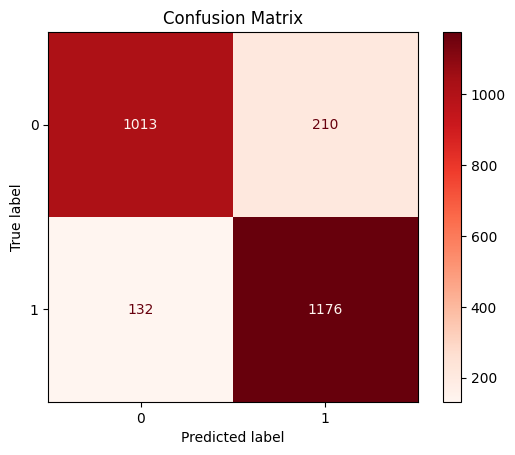

TN: 1013
FP: 210
FN: 132
TP: 1176


In [151]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, cmap="Reds")

plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

In [152]:
test_analysis = test_final.copy()

test_analysis["actual"] = y_test.values
test_analysis["predicted"] = test_pred
test_analysis["probability"] = test_prob

In [153]:
test_analysis.shape

(2531, 57)

In [154]:
false_positive = test_analysis[(test_analysis["actual"] == 0) & (test_analysis["predicted"] == 1)].sort_values("probability", ascending=False)
false_negative = test_analysis[(test_analysis["actual"] == 1) & (test_analysis["predicted"] == 0)].sort_values("probability")

print("False Positives ", false_positive.shape)
print("False Negatives ",false_negative.shape)


False Positives  (210, 57)
False Negatives  (132, 57)


## Error Analysis

In [155]:
false_negative.columns

Index(['hotel_id', 'gds_b_room_id', 'gds_b_room_name',
       'gds_b_room_description', 'gds_b_room_amenities', 'gds_b_bedding',
       'gds_b_room_type', 'gds_b_views', 'gds_b_smoking',
       'gds_b_accessibility', 'gds_b_amenities', 'gds_a_room_id',
       'gds_a_room_name', 'gds_a_room_description', 'gds_a_room_amenities',
       'gds_a_bedding', 'gds_a_room_type', 'gds_a_views', 'gds_a_smoking',
       'gds_a_accessibility', 'gds_a_amenities', 'gds_b_room_name_clean',
       'gds_b_room_description_clean', 'gds_b_bedding_clean',
       'gds_b_room_type_clean', 'gds_b_views_clean', 'gds_b_smoking_clean',
       'gds_b_accessibility_clean', 'gds_a_room_name_clean',
       'gds_a_room_description_clean', 'gds_a_room_amenities_clean',
       'gds_a_bedding_clean', 'gds_a_room_type_clean', 'gds_a_views_clean',
       'gds_a_smoking_clean', 'gds_a_accessibility_clean',
       'gds_a_amenities_clean', 'gds_b_smoking_imputed',
       'gds_a_smoking_imputed', 'gds_b_accessibility_imputed',

In [156]:
cols = ["hotel_id", "gds_b_room_id", "gds_a_room_id",  "gds_b_room_name_clean", "gds_a_room_name_clean",
        "gds_b_bedding_clean", "gds_a_bedding_clean", "gds_b_room_type_clean", "gds_a_room_type_clean", "gds_b_smoking_imputed", "gds_a_smoking_imputed", "gds_b_views_imputed", "gds_a_views_imputed",
        "room_name_token_sort_ratio", "room_name_token_set_ratio", "bedding_token_sort_ratio", "bedding_token_set_ratio", "room_type_match",
        "smoking_match", "views_match", "accessibility_match", "actual", "predicted", "probability"]

false_negative[cols].head(25).to_csv('25_false_negative_cases.csv', index = False)
false_positive[cols].head(25).to_csv('25_false_positive_cases.csv', index = False)

In [157]:
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss
0,Logistic Regression,0.834571,0.822155,0.868631,0.844754,0.902326,0.908277,0.399983
1,Random Forest,0.852723,0.847641,0.872611,0.859945,0.926571,0.923908,0.553184
2,XGBoost,0.862624,0.854727,0.885350,0.869769,0.932957,0.932746,0.339056
3,XGBoost - Final,0.864876,0.848485,0.899083,0.873051,0.940961,0.948741,0.309835


# Conclusion
This case study focused on building a machine learning pipeline to identify matching room pairs between two GDS providers. The approach included data cleaning, hotel-level train/validation/test splitting to prevent data leakage, generation of negative samples, feature engineering using room attributes and similarities, and evaluation of multiple classification models. Logistic Regression, Random Forest, and XGBoost were compared, with XGBoost achieved the best performance among the evaluated models.

The final XGBoost model was further improved through hyperparameter tuning using RandomizedSearchCV and probability threshold optimization. Instead of using the default classification threshold of 0.50, thresholds ranging from 0.10 to 0.90 were evaluated on the validation set, and a threshold of 0.40 was selected as it produced the highest F1-score. This threshold provided the best balance between precision and recall, allowing the model to recover a larger proportion of true room matches while maintaining a relatively low number of incorrect matches.

On the unseen test dataset, the final model achieved an **Accuracy of 86.48%**, **Precision of 84.84%**, **Recall of 89.90%**, **F1-score of 87.30%**, **ROC-AUC of 0.9409**, **PR-AUC of 0.9487**, and **Log Loss of 0.3098**.

For hotels with multiple candidate room combinations, the model assigns a probability score to every candidate room pair. These probabilities can be ranked to prioritize the most likely matches for downstream processing. In a production environment, the highest ranked candidate exceeding the decision threshold would typically be selected, while additional one-to-one matching constraints or business rules can be applied when multiple high confidence candidates exist.

## Further Improvement
Although the model got a strong performace, several enhancements can further improve the quality of the room matching system.
Below are some points:
* gds_b_amentites can be imputed from description.
* better domain specific keywords can be used to normalise the words and for pattern capturing.
* Instead of just using specific stop words we can use deafault stop words from nltk.
* We can use Language model to get the similarity for description.